In [4]:
# # Cài đặt các thư viện cần thiết
!pip install tensorflow
!pip install tokenizers
!pip install numpy

In [5]:


# Import thư viện
from google.colab import drive
import tensorflow as tf
import os
import json
import numpy as np
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Đường dẫn
data_dir = "/content/drive/MyDrive/NLPfinal"
save_dir = os.path.join(data_dir, "Transformer_train_model")
checkpoint_dir = os.path.join(save_dir, "checkpoints")
os.makedirs(save_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

Mounted at /content/drive


In [6]:


# Hàm tiền xử lý văn bản
def clean_text(text):
    return text.replace("_", " ").strip()

# Hàm tải dữ liệu từ JSON
def load_qa_from_json(file_path):
    questions = []
    responses = []
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for item in data:
            questions.append(clean_text(item['question']))
            responses.append(clean_text(item['response']))
    return questions, responses

# Tải dữ liệu
train_file = os.path.join(data_dir, "data_60k.json")
valid_file = os.path.join(data_dir, "valid.json")

# Nếu chưa có valid.json, chia 20% từ train.json
if not os.path.exists(valid_file) and os.path.exists(train_file):
    with open(train_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    train_size = int(0.8 * len(data))
    train_data = data[:train_size]
    valid_data = data[train_size:]

    with open(train_file, 'w', encoding='utf-8') as f:
        json.dump(train_data, f, ensure_ascii=False, indent=2)
    with open(valid_file, 'w', encoding='utf-8') as f:
        json.dump(valid_data, f, ensure_ascii=False, indent=2)

train_questions, train_responses = load_qa_from_json(train_file)
test_questions, test_responses = load_qa_from_json(valid_file)

# Kiểm tra dữ liệu
print(f"Train questions: {len(train_questions)}")
print(f"Train responses: {len(train_responses)}")
print(f"Test questions: {len(test_questions)}")
print(f"Test responses: {len(test_responses)}")
if not train_questions or not train_responses:
    raise ValueError("Train data is empty!")

Train questions: 48000
Train responses: 48000
Test questions: 12000
Test responses: 12000


In [7]:


# Hàm huấn luyện tokenizer BPE
def train_bpe_tokenizer(sentences, tokenizer_path=None, vocab_size=15000):
    if tokenizer_path is None:
        tokenizer_path = os.path.join(save_dir, "bpe_tokenizer.json")

    all_text_path = os.path.join(save_dir, "all_text.txt")
    with open(all_text_path, "w", encoding="utf-8") as f:
        for line in sentences:
            f.write(clean_text(line) + "\n")

    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"])
    tokenizer.train([all_text_path], trainer)
    tokenizer.save(tokenizer_path)
    print(f"✅ Tokenizer đã lưu tại: {tokenizer_path}")
    return tokenizer

In [8]:


# Huấn luyện hoặc load tokenizer
tokenizer_path = os.path.join(save_dir, "bpe_tokenizer.json")
if not os.path.exists(tokenizer_path):
    all_sentences = train_questions + train_responses + test_questions + test_responses
    tokenizer = train_bpe_tokenizer(all_sentences, tokenizer_path, vocab_size=15000)  # Tăng vocab_size
else:
    tokenizer = Tokenizer.from_file(tokenizer_path)

# Cấu hình tokenizer
MAX_LEN = 128  # Độ dài trung bình của câu khoảng 20-50 từ
tokenizer.enable_truncation(max_length=MAX_LEN)
VOCAB_SIZE = tokenizer.get_vocab_size()

# Hàm mã hóa câu
def encode_sentence(sentence, tokenizer):
    tokens = tokenizer.encode(clean_text(sentence))
    return tokens.ids

# Hàm mã hóa cặp câu hỏi-trả lời
def encode_pairs(sources, targets, tokenizer, max_len):
    inputs = []
    outputs = []
    bos_id = tokenizer.token_to_id("<bos>")
    eos_id = tokenizer.token_to_id("<eos>")
    for src, tgt in zip(sources, targets):
        input_ids = [bos_id] + encode_sentence(src, tokenizer)[:max_len-2] + [eos_id]
        output_ids = [bos_id] + encode_sentence(tgt, tokenizer)[:max_len-2] + [eos_id]
        inputs.append(input_ids)
        outputs.append(output_ids)
    return inputs, outputs

# Hàm padding
def pad_sequences(sequences, maxlen, pad_token_id):
    return tf.keras.preprocessing.sequence.pad_sequences(
        sequences, maxlen=maxlen, padding='post', truncating='post', value=pad_token_id
    )

# Xử lý dữ liệu
pad_token_id = tokenizer.token_to_id("<pad>")
train_inputs, train_outputs = encode_pairs(train_questions, train_responses, tokenizer, MAX_LEN)
test_inputs, test_outputs = encode_pairs(test_questions, test_responses, tokenizer, MAX_LEN)

train_inputs_padded = pad_sequences(train_inputs, MAX_LEN, pad_token_id)
train_outputs_padded = pad_sequences(train_outputs, MAX_LEN, pad_token_id)
test_inputs_padded = pad_sequences(test_inputs, MAX_LEN, pad_token_id)
test_outputs_padded = pad_sequences(test_outputs, MAX_LEN, pad_token_id)

# Chuẩn bị decoder inputs và outputs (shifted right)
train_dec_inputs = train_outputs_padded[:, :-1]  # Bỏ token cuối
train_dec_outputs = train_outputs_padded[:, 1:]  # Bỏ token đầu
test_dec_inputs = test_outputs_padded[:, :-1]
test_dec_outputs = test_outputs_padded[:, 1:]


In [9]:
# In thông tin tokenizer
print("🔤 Vocab size:", VOCAB_SIZE)
print("📏 Max length:", MAX_LEN)
print("<pad> ID:", tokenizer.token_to_id("<pad>"))
print("<bos> ID:", tokenizer.token_to_id("<bos>"))
print("<eos> ID:", tokenizer.token_to_id("<eos>"))

# In tất cả các dữ liệu huấn luyện và kiểm thử sau khi mã hóa và padding
print("\n=== IN DỮ LIỆU HUẤN LUYỆN ===")
for i in range(10):
    print(f"\n=== MẪU HUẤN LUYỆN {i+1} ===")
    print("Câu hỏi gốc:", train_questions[i])
    print("Câu trả lời gốc:", train_responses[i])

    print("Input đã mã hóa:", train_inputs[i])
    print("Input đã padding:", train_inputs_padded[i])

    print("Decoder input (shifted):", train_dec_inputs[i])
    print("Decoder output (shifted):", train_dec_outputs[i])

    # Giải mã để kiểm tra lại
    input_decoded = tokenizer.decode(train_inputs[i][1:-1])  # Bỏ <bos>, <eos>
    target_decoded = tokenizer.decode(train_outputs[i][1:-1])  # Bỏ <bos>, <eos>
    print("→ Input decoded:", input_decoded)
    print("→ Output decoded:", target_decoded)

print("\n=== IN DỮ LIỆU KIỂM THỬ ===")
for i in range(len(test_questions)):
    print(f"\n=== MẪU KIỂM THỬ {i+1} ===")
    print("Câu hỏi gốc:", test_questions[i])
    print("Câu trả lời gốc:", test_responses[i])

    print("Input đã mã hóa:", test_inputs[i])
    print("Input đã padding:", test_inputs_padded[i])

    print("Decoder input (shifted):", test_dec_inputs[i])
    print("Decoder output (shifted):", test_dec_outputs[i])

    # Giải mã để kiểm tra lại
    input_decoded = tokenizer.decode(test_inputs[i][1:-1])  # Bỏ <bos>, <eos>
    target_decoded = tokenizer.decode(test_outputs[i][1:-1])  # Bỏ <bos>, <eos>
    print("→ Input decoded:", input_decoded)
    print("→ Output decoded:", target_decoded)


Streaming output truncated to the last 5000 lines.
   12  388  402  690  319 1298    5 2114    5  590  262  394  241  239
  438  226  300  263  473  418  620  528  219  325   14  514  752  367
  450  227  364  303  233  223   14    2    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0]
Decoder output (shifted): [ 870  227  297 2205 2221  284  478  340  332   14  545  224 1145  226
  248  361  822  518   14  424  361  530  315  303  357  394  382   12
  388  402  690  319 1298    5 2114    5  590  262  394  241  239  438
  226  300  263  473  418  620  528  219  325   14  514  752  367  450
  227  364  303  233  223   14    2    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    

In [10]:

# Tạo dataset
BATCH_SIZE = 256  # Tăng batch size để huấn luyện nhanh hơn
train_dataset = tf.data.Dataset.from_tensor_slices((
    {"inputs": train_inputs_padded, "dec_inputs": train_dec_inputs},
    train_dec_outputs
)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {"inputs": test_inputs_padded, "dec_inputs": test_dec_inputs},
    test_dec_outputs
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Kiểm tra shape dataset
for batch in train_dataset.take(1):
    print("Train batch inputs shape:", batch[0]["inputs"].shape)
    print("Train batch dec_inputs shape:", batch[0]["dec_inputs"].shape)
    print("Train batch dec_outputs shape:", batch[1].shape)


Train batch inputs shape: (256, 128)
Train batch dec_inputs shape: (256, 127)
Train batch dec_outputs shape: (256, 127)


In [11]:
# Lớp ScaledDotProductAttention
class ScaledDotProductAttention(tf.keras.layers.Layer):
    def call(self, inputs):
        query, key, value, mask = inputs
        matmul_qk = tf.matmul(query, key, transpose_b=True)
        dk = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, value)
        return output


In [12]:


# Lớp MultiHeadAttention
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__(name=name)
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.query_dense = tf.keras.layers.Dense(d_model)
        self.key_dense = tf.keras.layers.Dense(d_model)
        self.value_dense = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

        self.attention = ScaledDotProductAttention()

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        query, key, value, mask = inputs['query'], inputs['key'], inputs['value'], inputs.get('mask')
        batch_size = tf.shape(query)[0]

        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        scaled_attention = self.attention([query, key, value, mask])
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
        output = self.dense(concat_attention)
        return output

In [13]:
# Lớp PositionalEncoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, position, i, d_model):
        angles = 1 / tf.math.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
            i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
            d_model=d_model
        )
        sines = tf.math.sin(angle_rads[:, 0::2])
        cosines = tf.math.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        # Nếu inputs là SparseTensor, chuyển thành Dense Tensor
        if isinstance(inputs, tf.SparseTensor):
            inputs = tf.sparse.to_dense(inputs)
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

In [14]:


# Hàm tạo padding mask
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]  # Shape: (batch_size, 1, 1, seq_len)

# Hàm tạo look-ahead mask
def create_look_ahead_mask(seq_len):
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask  # Shape: (seq_len, seq_len)

# Hàm kết hợp look-ahead mask và padding mask
def create_combined_mask(target):
    look_ahead_mask = create_look_ahead_mask(tf.shape(target)[1])
    padding_mask = create_padding_mask(target)
    return tf.maximum(look_ahead_mask, padding_mask)

# Hàm tạo encoder layer
def encoder_layer(units, d_model, num_heads, dropout, name="encoder_layer"):
    inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")
    attention = MultiHeadAttention(d_model, num_heads, name="attention")({
        'query': inputs, 'key': inputs, 'value': inputs, 'mask': padding_mask
    })
    attention = tf.keras.layers.Dropout(rate=dropout)(attention)
    attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs + attention)
    outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention)
    outputs = tf.keras.layers.Dense(units=d_model)(outputs)
    outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
    outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(outputs + attention)
    return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

# Hàm tạo encoder
def encoder(vocab_size, num_layers, units, d_model, num_heads, dropout, name="encoder"):
    inputs = tf.keras.Input(shape=(None,), name="inputs")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")
    embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
    embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
    embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
    outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)
    for i in range(num_layers):
        outputs = encoder_layer(
            units=units, d_model=d_model, num_heads=num_heads, dropout=dropout,
            name=f"encoder_layer_{i}"
        )([outputs, padding_mask])
    return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

# Hàm tạo decoder layer
def decoder_layer(units, d_model, num_heads, dropout, name="decoder_layer"):
    inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
    enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
    look_ahead_mask = tf.keras.Input(shape=(1, None, None), name="look_ahead_mask")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")
    attention1 = MultiHeadAttention(d_model, num_heads, name="attention_1")({
        'query': inputs, 'key': inputs, 'value': inputs, 'mask': look_ahead_mask
    })
    attention1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention1 + inputs)
    attention2 = MultiHeadAttention(d_model, num_heads, name="attention_2")({
        'query': attention1, 'key': enc_outputs, 'value': enc_outputs, 'mask': padding_mask
    })
    attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
    attention2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention2 + attention1)
    outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention2)
    outputs = tf.keras.layers.Dense(units=d_model)(outputs)
    outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
    outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(outputs + attention2)
    return tf.keras.Model(
        inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask], outputs=outputs, name=name
    )

# Hàm tạo decoder
def decoder(vocab_size, num_layers, units, d_model, num_heads, dropout, name="decoder"):
    inputs = tf.keras.Input(shape=(None,), name="inputs")
    enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
    look_ahead_mask = tf.keras.Input(shape=(1, None, None), name="look_ahead_mask")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")
    embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
    embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
    embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
    outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)
    for i in range(num_layers):
        outputs = decoder_layer(
            units=units, d_model=d_model, num_heads=num_heads, dropout=dropout,
            name=f"decoder_layer_{i}"
        )([outputs, enc_outputs, look_ahead_mask, padding_mask])
    return tf.keras.Model(
        inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask], outputs=outputs, name=name
    )

# Hàm tạo mô hình Transformer
def transformer(vocab_size, num_layers, units, d_model, num_heads, dropout, name="transformer"):
    inputs = tf.keras.Input(shape=(None,), name="inputs")
    dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

    # Tạo masks
    enc_padding_mask = tf.keras.layers.Lambda(
        create_padding_mask, output_shape=(1, 1, None), name='enc_padding_mask')(inputs)
    look_ahead_mask = tf.keras.layers.Lambda(
        create_combined_mask, output_shape=(1, None, None), name='look_ahead_mask')(dec_inputs)
    dec_padding_mask = tf.keras.layers.Lambda(
        create_padding_mask, output_shape=(1, 1, None), name='dec_padding_mask')(inputs)

    # Encoder
    enc_outputs = encoder(
        vocab_size=vocab_size, num_layers=num_layers, units=units, d_model=d_model,
        num_heads=num_heads, dropout=dropout
    )([inputs, enc_padding_mask])

    # Decoder
    dec_outputs = decoder(
        vocab_size=vocab_size, num_layers=num_layers, units=units, d_model=d_model,
        num_heads=num_heads, dropout=dropout
    )([dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

    # Đầu ra
    outputs = tf.keras.layers.Dense(units=vocab_size)(dec_outputs)

    return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)

# Định nghĩa CustomSchedule
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=8000):
        super(CustomSchedule, self).__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):
        return {"d_model": self.d_model, "warmup_steps": self.warmup_steps}

# Hàm mất mát
def loss_function(y_true, y_pred):
    loss = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none')(y_true, y_pred)
    mask = tf.cast(tf.math.not_equal(y_true, 0), dtype=tf.float32)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

# Hàm độ chính xác
def accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, y_pred.dtype)
    accuracies = tf.cast(tf.equal(y_true, y_pred), tf.float32)
    mask = tf.cast(tf.math.not_equal(y_true, 0), tf.float32)
    accuracies *= mask
    return tf.reduce_sum(accuracies) / tf.reduce_sum(mask)

In [15]:
# Siêu tham số
NUM_LAYERS = 4  # Giảm số layer để tối ưu hiệu suất
D_MODEL = 128
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1
EPOCHS = 50  # Tăng số epoch để học tốt ngữ cảnh trò chuyện

# Khởi tạo mô hình
model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

# Cấu hình huấn luyện
learning_rate = CustomSchedule(D_MODEL, warmup_steps=8000)
optimizer = tf.keras.optimizers.Adam(
    learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9
)

model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])

# Callbacks
# Callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'checkpoint-{epoch:02d}.h5'),  # Đổi đuôi thành .h5 để lưu đầy đủ mô hình
    save_weights_only=False,  # Lưu đầy đủ mô hình
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs')

# Load weights từ checkpoint nếu có
checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint-01.h5')
if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)


In [14]:
# Huấn luyện mô hình
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback, early_stopping, tensorboard_callback],
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.3036 - loss: 4.0678
Epoch 1: val_loss improved from inf to 3.90835, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-01.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 166s 589ms/step - accuracy: 0.3036 - loss: 4.0678 - val_accuracy: 0.3180 - val_loss: 3.9084
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3093 - loss: 3.9724
Epoch 2: val_loss improved from 3.90835 to 3.74296, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-02.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 86s 458ms/step - accuracy: 0.3093 - loss: 3.9722 - val_accuracy: 0.3269 - val_loss: 3.7430
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.3206 - loss: 3.7869
Epoch 3: val_loss improved from 3.74296 to 3.53528, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-03.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 136s 428ms/step - accuracy: 0.3207 - loss: 3.7866 - val_accuracy: 0.3409 - val_loss: 3.5353
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3354 - loss: 3.5752
Epoch 4: val_loss improved from 3.53528 to 3.32871, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-04.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 429ms/step - accuracy: 0.3354 - loss: 3.5750 - val_accuracy: 0.3577 - val_loss: 3.3287
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.3528 - loss: 3.3706
Epoch 5: val_loss improved from 3.32871 to 3.13598, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-05.h5


...

188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 406ms/step - accuracy: 0.6110 - loss: 1.5150 - val_accuracy: 0.6013 - val_loss: 1.5947
Epoch 43/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6125 - loss: 1.5050
Epoch 43: val_loss did not improve from 1.59468
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 400ms/step - accuracy: 0.6125 - loss: 1.5049 - val_accuracy: 0.6013 - val_loss: 1.5953
Epoch 44/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6139 - loss: 1.4960
Epoch 44: val_loss improved from 1.59468 to 1.59122, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-44.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.6139 - loss: 1.4960 - val_accuracy: 0.6016 - val_loss: 1.5912
Epoch 45/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6159 - loss: 1.4847
Epoch 45: val_loss improved from 1.59122 to 1.58344, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-45.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 76s 406ms/step - accuracy: 0.6159 - loss: 1.4847 - val_accuracy: 0.6034 - val_loss: 1.5834
Epoch 46/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6174 - loss: 1.4753
Epoch 46: val_loss did not improve from 1.58344
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 422ms/step - accuracy: 0.6174 - loss: 1.4752 - val_accuracy: 0.6028 - val_loss: 1.5835
Epoch 47/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6188 - loss: 1.4665
Epoch 47: val_loss did not improve from 1.58344
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 401ms/step - accuracy: 0.6188 - loss: 1.4664 - val_accuracy: 0.6024 - val_loss: 1.5853
Epoch 48/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6207 - loss: 1.4573
Epoch 48: val_loss did not improve from 1.58344
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 402ms/step - accuracy: 0.6207 - loss: 1.4573 - val_accuracy: 0.6030 - val_loss: 1.5858
Epoch 49/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6224 - loss: 1.4484
Epoch 49: val_loss i

188/188 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.6224 - loss: 1.4484 - val_accuracy: 0.6038 - val_loss: 1.5774
Epoch 50/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6237 - loss: 1.4404
Epoch 50: val_loss improved from 1.57745 to 1.57488, saving model to /content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-50.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 406ms/step - accuracy: 0.6237 - loss: 1.4404 - val_accuracy: 0.6042 - val_loss: 1.5749
Restoring model weights from the end of the best epoch: 50.


In [15]:
# Lưu mô hình
model_save_path = os.path.join(save_dir, "saved_modelver3")

# Định nghĩa signature cho inference
@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, None], dtype=tf.int32, name="inputs"),
    tf.TensorSpec(shape=[None, None], dtype=tf.int32, name="dec_inputs"),
])
def serving_fn(inputs, dec_inputs):
    return {"output": model([inputs, dec_inputs], training=False)}

tf.saved_model.save(
    model,
    model_save_path,
    signatures={'serving_default': serving_fn}
)
print(f"✅ Mô hình đã lưu tại: {model_save_path}")


✅ Mô hình đã lưu tại: /content/drive/MyDrive/NLPfinal/Transformer_train_model/saved_modelver3


In [16]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and

In [16]:
def beam_search_decoder(input_text, model, tokenizer, max_length=512, beam_width=3):
    inputs = tokenizer.encode(input_text)
    input_ids = tf.constant([inputs.ids], dtype=tf.int32)

    # Khởi tạo beam search
    start_token = tokenizer.token_to_id("<bos>")
    end_token = tokenizer.token_to_id("<eos>")
    beams = [(tf.constant([[start_token]], dtype=tf.int32), 0.0)]  # (sequence, score)

    for _ in range(max_length):
        new_beams = []
        for sequence, score in beams:
            # Nếu đã kết thúc thì ưu tiên
            if sequence[0, -1] == end_token:
                new_beams.append((sequence, score + 1.0))  # Ưu tiên chuỗi đã kết thúc
                continue

            predictions = model([input_ids, sequence], training=False)
            logits = predictions[:, -1, :]  # Logits của token cuối
            log_probs = tf.nn.log_softmax(logits, axis=-1)

            top_k_probs, top_k_indices = tf.nn.top_k(log_probs, k=beam_width)
            top_k_probs = top_k_probs[0].numpy()
            top_k_indices = top_k_indices[0].numpy()

            for prob, idx in zip(top_k_probs, top_k_indices):
                new_sequence = tf.concat([sequence, tf.constant([[idx]], dtype=tf.int32)], axis=-1)
                new_score = score + prob
                new_beams.append((new_sequence, new_score))

        # Giữ lại top beam_width beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        # Dừng nếu tất cả đều đã kết thúc
        if all(seq[0, -1] == end_token for seq, _ in beams):
            break

    # Lấy beam tốt nhất
    best_sequence, _ = beams[0]
    output_ids = best_sequence[0, 1:].numpy()  # Bỏ <bos>
    output_text = tokenizer.decode(output_ids, skip_special_tokens=True)

    # Hậu xử lý nếu quá ngắn hoặc không hợp lệ
    if not output_text.strip():
        output_text = "Xin lỗi, mình chưa hiểu rõ câu hỏi. Cậu có thể nói rõ hơn không?"

    return output_text

# Cấu hình giống lúc huấn luyện
VOCAB_SIZE = tokenizer.get_vocab_size()
NUM_LAYERS = 4
D_MODEL = 128
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1

# Tạo mô hình và load trọng số
model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

model.load_weights("/content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-50.h5")
print("✅ Đã load thành công checkpoint.")

# Thử nghiệm
inputs = [
    "Có một người cứ 'thả thính' mình, quan tâm mình lắm, làm mình rung động rồi hy vọng. Nhưng khi mình có vẻ bật đèn xanh thì người ta lại lùi về, chỉ xem như bạn bè. Rồi một thời gian sau lại quay lại quan tâm. Cứ lặp đi lặp lại vậy làm mình thấy như bị 'đùa giỡn' vậy á.",
    "Mình thích bạn thân của mình hơn một năm rồi, phải làm sao đây?",
    "Mình chia tay người yêu được một thời gian rồi, lý trí thì biết là kết thúc thật rồi, nhưng trái tim thì cứ mãi vương vấn. Vẫn còn thói quen vào xem story người ta, xem người ta có đi đâu, làm gì. Cảm giác cứ lẩn quẩn trong quá khứ mãi không thoát ra được."
]

for input_text in inputs:
    output = beam_search_decoder(input_text, model, tokenizer)
    print(f"👤 {input_text}\n🤖 {output}\n")


✅ Đã load thành công checkpoint.
👤 Có một người cứ 'thả thính' mình, quan tâm mình lắm, làm mình rung động rồi hy vọng. Nhưng khi mình có vẻ bật đèn xanh thì người ta lại lùi về, chỉ xem như bạn bè. Rồi một thời gian sau lại quay lại quan tâm. Cứ lặp đi lặp lại vậy làm mình thấy như bị 'đùa giỡn' vậy á.
🤖 Ôi , cái cảm giác bị ' thả thính ' hay ' thả thính ' từ người mình thích thật sự rất khó chịu và làm mình tổn thương . Có thể họ chưa sẵn sàng cho một mối quan hệ rõ ràng , hoặc có thể họ chưa sẵn sàng cho một mối quan hệ rõ ràng . Thay vì cứ đoán già đoán non , sao cậu không thử tập trung vào bản thân mình xem sao ?

👤 Mình thích bạn thân của mình hơn một năm rồi, phải làm sao đây?
🤖 Làm bạn thân với người mình thích thật sự là một thử thách lớn . Hãy dành thời gian chăm sóc bản thân , làm những điều mình thích , và dần dần dần dần xây dựng lại lòng tin nhé .

👤 Mình chia tay người yêu được một thời gian rồi, lý trí thì biết là kết thúc thật rồi, nhưng trái tim thì cứ mãi vương vấn. 

In [17]:
!pip install rouge-score nltk

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=09a9c3c60fe5fa13c9d4d4c02cff0dc73b2081559ae4fcd1af316d78de8f89b9
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Đã load thành công checkpoint.

🧪 Câu 1
Question: Người yêu mình quá tập trung vào việc xây dựng các mối quan hệ 'có lợi' cho sự nghiệp, đôi khi mình cảm thấy họ quan tâm đến những mối quan hệ đó hơn là mối quan hệ của hai đứa.
Ground Truth: Việc người yêu xây dựng các mối quan hệ xã hội phục vụ cho sự nghiệp là điều bình thường trong thế giới hiện đại. Tuy nhiên, nếu điều đó làm cậu cảm thấy không được ưu tiên và bị bỏ lại phía sau, hãy trò chuyện với người ấy về cảm giác của cậu nhé. Tình yêu cần sự vun đắp và thời gian chất lượng từ cả hai phía.
Predicted: Cảm giác không được ưu tiên trong mối quan hệ có thể làm mình cảm thấy không được trân trọng và không được trân trọng . Hãy nói chuyện với người yêu về cảm giác của cậu nhé . Chia sẻ rằng cậu mong muốn sự quan tâm và sự quan tâm từ họ nhiều hơn . Một mối quan hệ lành mạnh cần có sự cân bằng và tôn trọng lẫn nhau .

🧪 Câu 2
Question: Tớ lỡ thích một người nhưng họ lại đang trong một mối quan hệ 'đóng' nhưng có vẻ không hạnh phúc.

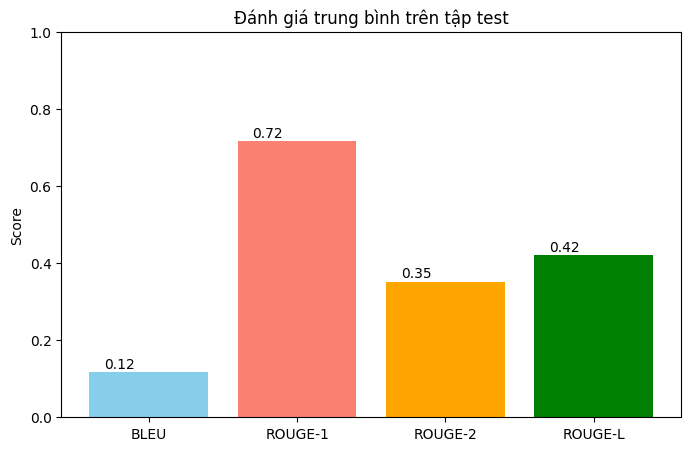

In [18]:
import json
import nltk
import tensorflow as tf
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

nltk.download('punkt')  # Tải tokenizer nếu cần

# Cấu hình smoothing
smoothie = SmoothingFunction().method4

# ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# ========================== BEAM SEARCH DECODER ==========================

def beam_search_decoder(input_text, model, tokenizer, max_length=80, beam_width=3):
    inputs = tokenizer.encode(input_text)
    input_ids = tf.constant([inputs.ids], dtype=tf.int32)

    start_token = tokenizer.token_to_id("<bos>")
    end_token = tokenizer.token_to_id("<eos>")
    beams = [(tf.constant([[start_token]], dtype=tf.int32), 0.0)]  # (sequence, score)

    for _ in range(max_length):
        new_beams = []
        for sequence, score in beams:
            if sequence[0, -1] == end_token:
                new_beams.append((sequence, score + 1.0))
                continue

            predictions = model([input_ids, sequence], training=False)
            logits = predictions[:, -1, :]
            log_probs = tf.nn.log_softmax(logits, axis=-1)

            top_k_probs, top_k_indices = tf.nn.top_k(log_probs, k=beam_width)
            top_k_probs = top_k_probs[0].numpy()
            top_k_indices = top_k_indices[0].numpy()

            for prob, idx in zip(top_k_probs, top_k_indices):
                new_sequence = tf.concat([sequence, tf.constant([[idx]], dtype=tf.int32)], axis=-1)
                new_score = score + prob
                new_beams.append((new_sequence, new_score))

        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        if all(seq[0, -1] == end_token for seq, _ in beams):
            break

    best_sequence, _ = beams[0]
    output_ids = best_sequence[0, 1:].numpy()
    output_text = tokenizer.decode(output_ids, skip_special_tokens=True)

    if not output_text.strip():
        output_text = "Xin lỗi, mình chưa hiểu rõ câu hỏi. Cậu có thể nói rõ hơn không?"

    return output_text

# ======================= LOAD MÔ HÌNH TRANSFORMER =======================

# Tham số cấu hình mô hình (giống lúc train)
VOCAB_SIZE = tokenizer.get_vocab_size()
NUM_LAYERS = 4
D_MODEL = 128
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1

# Khởi tạo và load trọng số mô hình
model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)
model.load_weights("/content/drive/MyDrive/NLPfinal/Transformer_train_model/checkpoints/checkpoint-50.h5")
print("✅ Đã load thành công checkpoint.")

# =========================== ĐÁNH GIÁ TẬP TEST ==========================

test_data_path = "/content/drive/MyDrive/NLPfinal/valid.json"
with open(test_data_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# Chỉ lấy 3 mẫu để test nhanh
test_data = test_data[:100]

# Lưu điểm
bleu_scores = []
rouge_1_scores = []
rouge_2_scores = []
rouge_l_scores = []

for i, item in enumerate(test_data):
    try:
        predicted = beam_search_decoder(item["question"], model, tokenizer)
        reference = item["response"]

        print(f"\n🧪 Câu {i+1}")
        print(f"Question: {item['question']}")
        print(f"Ground Truth: {reference}")
        print(f"Predicted: {predicted}")

        bleu = sentence_bleu([reference.split()], predicted.split(), smoothing_function=smoothie)
        bleu_scores.append(bleu)

        rouge = scorer.score(reference, predicted)
        rouge_1_scores.append(rouge['rouge1'].fmeasure)
        rouge_2_scores.append(rouge['rouge2'].fmeasure)
        rouge_l_scores.append(rouge['rougeL'].fmeasure)

    except Exception as e:
        print(f"❌ Lỗi ở mẫu {i}: {e}")

# =========================== HIỂN THỊ KẾT QUẢ ===========================

print("\n📊 Kết quả trung bình:")
print(f"BLEU: {sum(bleu_scores)/len(bleu_scores):.4f}")
print(f"ROUGE-1: {sum(rouge_1_scores)/len(rouge_1_scores):.4f}")
print(f"ROUGE-2: {sum(rouge_2_scores)/len(rouge_2_scores):.4f}")
print(f"ROUGE-L: {sum(rouge_l_scores)/len(rouge_l_scores):.4f}")

# =========================== VẼ BIỂU ĐỒ KẾT QUẢ ==========================

labels = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
averages = [
    sum(bleu_scores)/len(bleu_scores),
    sum(rouge_1_scores)/len(rouge_1_scores),
    sum(rouge_2_scores)/len(rouge_2_scores),
    sum(rouge_l_scores)/len(rouge_l_scores),
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, averages, color=['skyblue', 'salmon', 'orange', 'green'])
plt.ylim(0, 1)
plt.title("Đánh giá trung bình trên tập test")
plt.ylabel("Score")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.01, f"{yval:.2f}")

plt.show()
